IMU = ok pour 1 faire boucle
CALIB = ok donne les mat et dist



In [15]:
import numpy as np
import cv2
import pickle
from traitement_imu import Dataframe_IMU
from ops.generate_cloud import generate_cloud  

In [16]:

PATH_GAUCHE_CALIB = "/Users/pgpetitmangin/underwater/Underwater_Software/SLAM/calibration/param/stereo_params_complets.pkl"
PATH_DROITE_CALIB = "..."
CSV_IMU = "/Users/pgpetitmangin/underwater/Underwater_Software/SLAM/messages.csv"



In [28]:
#Ouverture des args pour calibrage
def take_pickle_args(chemin_calibrage: str) -> tuple:
    with open(chemin_calibrage, 'rb') as f:
        l_recupere = pickle.load(f)
        

    mtx = l_recupere['mtx1']
    dist = l_recupere['dist1']
    P1 = np.array(l_recupere['P1'])
    newcameramtx = P1[:3, :3]
    roi = l_recupere['roi1']
    
    return mtx, dist, newcameramtx, roi



In [29]:
#convertir angles d'euler en matrice de rotation pour optim de l'IMU
def euler_to_R(roll: float, pitch: float, yaw: float) -> np.ndarray:
    roll_mat = np.array([
        [1, 0, 0],
        [0, np.cos(roll), -np.sin(roll)],
        [0, np.sin(roll),  np.cos(roll)]
    ])

    pitch_mat = np.array([
        [ np.cos(pitch), 0, np.sin(pitch)],
        [0,              1, 0],
        [-np.sin(pitch), 0, np.cos(pitch)]
    ])

    yaw_mat = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0,            0,           1]
    ])

    return yaw_mat @ pitch_mat @ roll_mat

In [30]:
#distorsion
mtx_G, dist_G, newcameramtx_G, roi_G = take_pickle_args(PATH_GAUCHE_CALIB)
K_G = newcameramtx_G
dist_coeffs_G = dist_G

In [31]:
#form ation du df de l'imu
df_imu_obj = Dataframe_IMU(CSV_IMU)
df_imu_obj.apply()
df_imu = df_imu_obj.get_dataframe().copy()

print(df_imu.head())

     time_ms      roll     pitch       yaw  rollspeed  pitchspeed  yawspeed
0  2708631.0  0.045759  0.123507 -1.428029   0.018112   -0.012048 -0.047215
1  2708731.0  0.046169  0.120750 -1.432842   0.002665   -0.039461 -0.039537
2  2708831.0  0.045257  0.115065 -1.436656  -0.010552   -0.068163 -0.026247
3  2708931.0  0.042961  0.106861 -1.439323  -0.026817   -0.088691 -0.015764
4  2709031.0  0.038903  0.097108 -1.441275  -0.045829   -0.100326 -0.009926


In [32]:
fps = 30
k = 0   

t_image = k / fps * 1000.0   # ms

idx = (df_imu["time_ms"] - t_image).abs().idxmin()

roll = float(df_imu.loc[idx, "roll"])
pitch = float(df_imu.loc[idx, "pitch"])
yaw = float(df_imu.loc[idx, "yaw"])

R_init = euler_to_R(roll, pitch, yaw)
rvec_init, _ = cv2.Rodrigues(R_init)

# translation initiale grossière
tvec_init = np.zeros((3, 1), dtype=np.float64)

(1920, 1080)
map done
Temps : 0.0429 secondes
Matchs trouvés : 3487
--- Résultats AKAZE ---
# Keypoints Gauche:   	 25214
# Keypoints Droite:   	 27166
# Matchs valides :	 2923


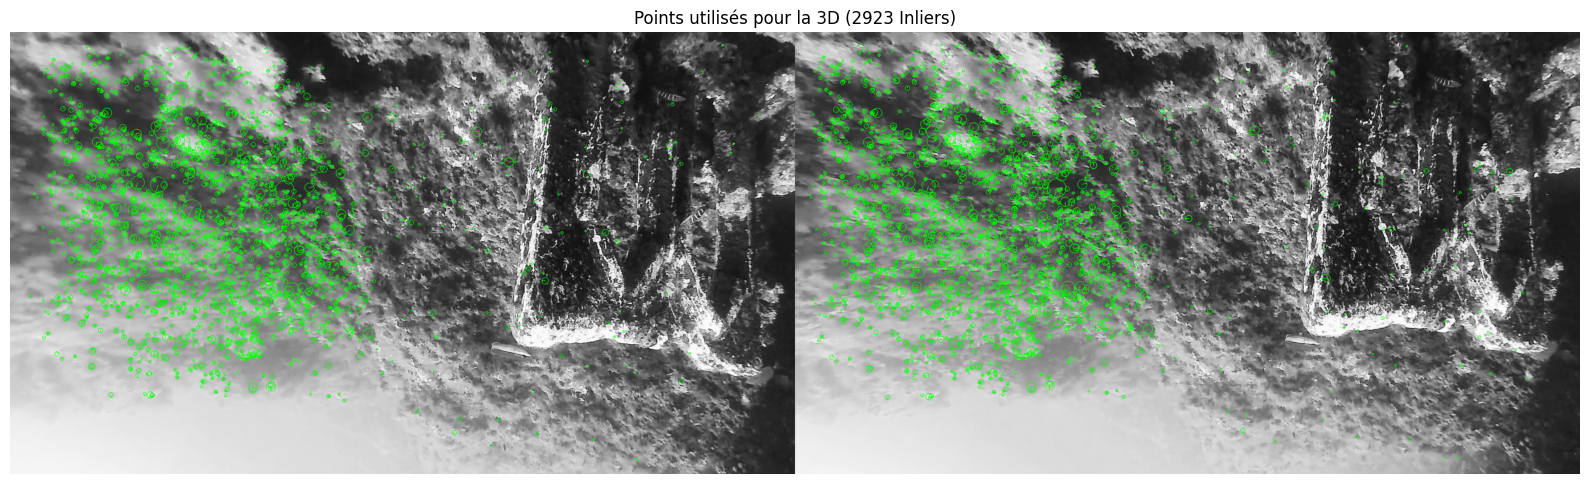

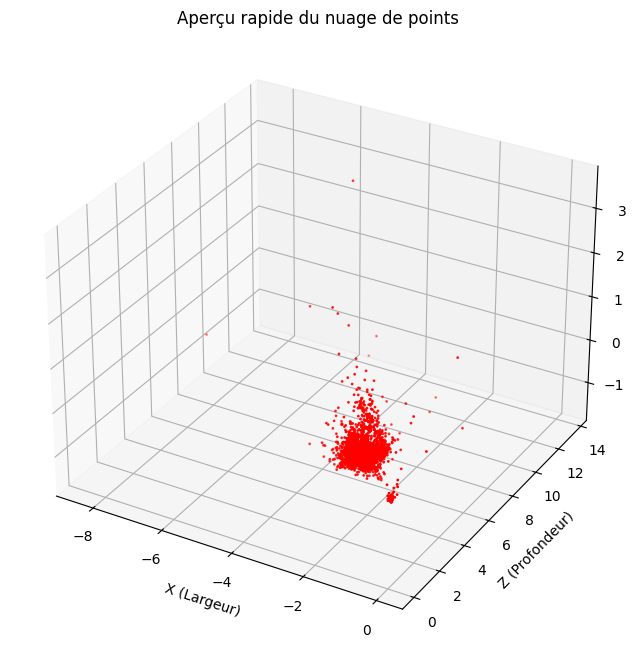

p3d shape: (2848, 3)
pts_2d shape: (2848, 2)
Points après clean: 2831


In [33]:
path_img_D ='/Users/pgpetitmangin/underwater/Underwater_Software/SLAM/data_sortie_mer/frames/droite/sortie_right.mp4_fixed/frames/frame_005138.jpg'
path_img_G = '/Users/pgpetitmangin/underwater/Underwater_Software/SLAM/data_sortie_mer/frames/gauche/sortie_left.mp4_fixed/frames/frame_005138.jpg'
p3d, pts_2d, _ = generate_cloud(path_img_G, path_img_D)



print("p3d shape:", p3d.shape)
print("pts_2d shape:", pts_2d.shape)

assert p3d.shape[0] == pts_2d.shape[0]
assert p3d.shape[1] == 3
assert pts_2d.shape[1] == 2

# nettoyage
mask_valid = np.isfinite(p3d).all(axis=1)
p3d = p3d[mask_valid]
pts_2d = pts_2d[mask_valid]

mask_depth = (p3d[:, 2] > 0.2) & (p3d[:, 2] < 10)
p3d = p3d[mask_depth]
pts_2d = pts_2d[mask_depth]

print("Points après clean:", len(p3d))

# normalisation
mean = np.mean(p3d, axis=0)
p3d = p3d - mean

In [34]:
success, rvec, tvec, inliers = cv2.solvePnPRansac(
    p3d,
    pts_2d,
    K_G,
    dist_coeffs_G,
    rvec=rvec_init,
    tvec=tvec_init,
    useExtrinsicGuess=True,
    iterationsCount=100,
    reprojectionError=3.0,
    confidence=0.99,
    flags=cv2.SOLVEPNP_ITERATIVE
)

if not success or inliers is None:
    raise RuntimeError("PnP failed")

In [35]:
p3d_in = p3d[inliers[:, 0]]
pts_2d_in = pts_2d[inliers[:, 0]]

success, rvec, tvec = cv2.solvePnP(
    p3d_in,
    pts_2d_in,
    K_G,
    dist_coeffs_G,
    rvec=rvec,
    tvec=tvec,
    useExtrinsicGuess=True,
    flags=cv2.SOLVEPNP_ITERATIVE
)

if not success:
    raise RuntimeError("Refined PnP failed")

In [37]:

proj, _ = cv2.projectPoints(p3d_in, rvec, tvec, K_G, dist_coeffs_G)
proj = proj.reshape(-1, 2)

error = np.mean(np.linalg.norm(proj - pts_2d_in, axis=1))
print("Reprojection error:", error)

R_final, _ = cv2.Rodrigues(rvec)
print("R_final =\n", R_final)
print("t_final =\n", tvec)

Reprojection error: 4484672000.0
R_final =
 [[ 0.87915088  0.46868453  0.08618903]
 [-0.46483431  0.88325345 -0.06158248]
 [-0.10498952  0.01407668  0.9943737 ]]
t_final =
 [[-0.23918296]
 [ 0.00359179]
 [ 0.00246387]]
